In [1]:
import os
import sys
import argparse

import numpy as np
import matplotlib.pyplot as plt

import torch

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

from data_generation.differential_equations import ElasticityLeastSquares
from utils import load_yaml, load_pkl, load_npy, format_elapsed_time, timing, plot_complex_valued_function, plot_real_valued_function

from scifem import create_real_functionspace

import torch
import torch.nn as nn
import torch.nn.init as init
import numpy as np
from petsc4py import PETSc
import scifem

from utils import project, norm_L2, convert_petsc_mat_to_torch_sparse_coo_tensor
from utils import evaluate_expression
from typing import Optional
import pickle

----------------------------------------
2025-11-20 15:59:43 - Start Program
----------------------------------------


In [2]:
mesh_config_path= repo_path + "/configs/elasticity/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/elasticity/config_data/config_function_space.yaml"
output_reduced_basis_config_path= repo_path + "/configs/elasticity/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/elasticity/train_dataset"
test_dataset_path = repo_path + "/results/elasticity/test_dataset"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)
elasticity_least_squares = ElasticityLeastSquares(mesh_args, function_space_args)

In [3]:
p_dof = load_npy(test_dataset_path+'/p_dof.npy')
sigma_u_dof = load_npy(test_dataset_path+'/sigma_u_dof.npy')
mean_p_dof = np.mean(load_npy(train_dataset_path+'/p_dof.npy'), axis=0) # use train dataset mean

In [4]:
print("p_dof shape: ", p_dof.shape)
print("sigma_u_dof shape: ", sigma_u_dof.shape)
# print("p_dof: ", p_dof)
# print("sigma_u_dof: ", sigma_u_dof)

p_dof shape:  (500, 8385)
sigma_u_dof shape:  (500, 230914)


In [5]:
Vh = elasticity_least_squares.Vh
mesh = elasticity_least_squares.mesh
dtype = torch.float64

In [6]:
sample_index = 1

sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
sigma_u_fc.x.array[:] = sigma_u_dof[sample_index]
sigma_fc = sigma_u_fc.sub(0).collapse()
sigma1_fc = sigma_fc.sub(0).collapse()
sigma2_fc = sigma_fc.sub(1).collapse()
u_fc = sigma_u_fc.sub(1).collapse()
u1_fc = u_fc.sub(0).collapse()
u2_fc = u_fc.sub(1).collapse()

p_fc = dolfinx.fem.Function(Vh['p'])
p_fc.x.array[:] = p_dof[sample_index]

mean_p_fc = dolfinx.fem.Function(Vh['p'])
mean_p_fc.x.array[:] = mean_p_dof

In [7]:
dolfinx_mesh_coords = mesh.geometry.x
CG1_u1_fc = dolfinx.fem.Function(Vh['CG1'])
CG1_u1_fc.x.array[:][scifem.vertex_to_dofmap(Vh['CG1'])] = evaluate_expression(mesh, u_fc, dolfinx_mesh_coords)[1][:, 0]
CG1_u2_fc = dolfinx.fem.Function(Vh['CG1'])
CG1_u2_fc.x.array[:][scifem.vertex_to_dofmap(Vh['CG1'])] = evaluate_expression(mesh, u_fc, dolfinx_mesh_coords)[1][:, 1]
CG1_u_fc = dolfinx.fem.Function(Vh['CG1_vector'])
CG1_u_fc.x.array[:] = np.stack([CG1_u1_fc.x.array, CG1_u2_fc.x.array], axis=1).reshape(-1)
print(f'evaluation difference between u1_fc and CG1_u1_fc: {abs(evaluate_expression(mesh, u1_fc, mesh.geometry.x)[1] - evaluate_expression(mesh, CG1_u1_fc, mesh.geometry.x)[1]).max()}')
print(f'evaluation difference between u2_fc and CG1_u2_fc: {abs(evaluate_expression(mesh, u2_fc, mesh.geometry.x)[1] - evaluate_expression(mesh, CG1_u2_fc, mesh.geometry.x)[1]).max()}')
print(f'evaluation difference between u_fc and CG1_u_fc: {abs(evaluate_expression(mesh, u_fc, mesh.geometry.x)[1] - evaluate_expression(mesh, CG1_u_fc, mesh.geometry.x)[1]).max()}')

evaluation difference between u1_fc and CG1_u1_fc: 0.0
evaluation difference between u2_fc and CG1_u2_fc: 0.0
evaluation difference between u_fc and CG1_u_fc: 0.0


In [8]:
CG1_sigma11_fc = dolfinx.fem.Function(Vh['CG1'])
CG1_sigma11_fc.x.array[:][scifem.vertex_to_dofmap(Vh['CG1'])] = evaluate_expression(mesh, sigma_fc, dolfinx_mesh_coords)[1][:, 0]
CG1_sigma12_fc = dolfinx.fem.Function(Vh['CG1'])
CG1_sigma12_fc.x.array[:][scifem.vertex_to_dofmap(Vh['CG1'])] = evaluate_expression(mesh, sigma_fc, dolfinx_mesh_coords)[1][:, 1]
CG1_sigma1_fc = dolfinx.fem.Function(Vh['CG1_vector'])
CG1_sigma1_fc.x.array[:] = np.stack([CG1_sigma11_fc.x.array, CG1_sigma12_fc.x.array], axis=1).reshape(-1)


CG1_sigma21_fc = dolfinx.fem.Function(Vh['CG1'])
CG1_sigma21_fc.x.array[:][scifem.vertex_to_dofmap(Vh['CG1'])] = evaluate_expression(mesh, sigma_fc, dolfinx_mesh_coords)[1][:, 2]
CG1_sigma22_fc = dolfinx.fem.Function(Vh['CG1'])
CG1_sigma22_fc.x.array[:][scifem.vertex_to_dofmap(Vh['CG1'])] = evaluate_expression(mesh, sigma_fc, dolfinx_mesh_coords)[1][:, 3]
CG1_sigma2_fc = dolfinx.fem.Function(Vh['CG1_vector'])
CG1_sigma2_fc.x.array[:] = np.stack([CG1_sigma21_fc.x.array, CG1_sigma22_fc.x.array], axis=1).reshape(-1)

CG1_sigma_fc = dolfinx.fem.Function(Vh['CG1_tensor'])
Vh_CG1_sigma1, Vh_CG1_sigma1_map = Vh['CG1_tensor'].sub(0).collapse()
Vh_CG1_sigma2, Vh_CG1_sigma2_map = Vh['CG1_tensor'].sub(1).collapse()
CG1_sigma_fc.x.array[np.sort(Vh_CG1_sigma1_map)] = CG1_sigma1_fc.x.array # we have to sort the indices in CG (possibly due to some bug in dolfinx)
CG1_sigma_fc.x.array[np.sort(Vh_CG1_sigma2_map)] = CG1_sigma2_fc.x.array


print(f'evaluation difference between sigma1_fc and CG1_sigma1_fc: {abs(evaluate_expression(mesh, sigma1_fc, mesh.geometry.x)[1] - evaluate_expression(mesh, CG1_sigma1_fc, mesh.geometry.x)[1]).max()}')
print(f'evaluation difference between sigma2_fc and CG1_sigma2_fc: {abs(evaluate_expression(mesh, sigma2_fc, mesh.geometry.x)[1] - evaluate_expression(mesh, CG1_sigma2_fc, mesh.geometry.x)[1]).max()}')
print(f'evaluation difference between sigma_fc and CG1_sigma_fc: {abs(evaluate_expression(mesh, sigma_fc, mesh.geometry.x)[1] - evaluate_expression(mesh, CG1_sigma_fc, mesh.geometry.x)[1]).max()}')

evaluation difference between sigma1_fc and CG1_sigma1_fc: 0.0
evaluation difference between sigma2_fc and CG1_sigma2_fc: 0.0
evaluation difference between sigma_fc and CG1_sigma_fc: 0.0


In [9]:
CG1_sigma_u_fc = dolfinx.fem.Function(Vh['CG1_tensor_vector'])
Vh_CG1_sigma, Vh_CG1_sigma_map = Vh['CG1_tensor_vector'].sub(0).collapse()
Vh_CG1_u, Vh_CG1_u_map = Vh['CG1_tensor_vector'].sub(1).collapse()
CG1_sigma_u_fc.x.array[np.sort(Vh_CG1_sigma_map)] = CG1_sigma_fc.x.array
CG1_sigma_u_fc.x.array[np.sort(Vh_CG1_u_map)] = CG1_u_fc.x.array
print(f'evaluation difference between sigma_u_fc and CG1_sigma_u_fc: {abs(evaluate_expression(mesh, sigma_u_fc, mesh.geometry.x)[1] - evaluate_expression(mesh, CG1_sigma_u_fc, mesh.geometry.x)[1]).max()}')

evaluation difference between sigma_u_fc and CG1_sigma_u_fc: 0.0


In [10]:
compute_L2_norm = elasticity_least_squares.compute_L2_norm

In [11]:
print(f'relative L2 error between sigma_fc and CG1_sigma_fc : {compute_L2_norm(sigma_fc - CG1_sigma_fc) / compute_L2_norm(sigma_fc) :.2e}')
print(f'relative L2 error between u_fc and CG1_u_fc : {compute_L2_norm(u_fc - CG1_u_fc) / compute_L2_norm(u_fc) :.2e}')
print(f'relative L2 error between sigma_u_fc and CG1_sigma_u_fc : {compute_L2_norm(sigma_u_fc - CG1_sigma_u_fc) / compute_L2_norm(sigma_u_fc) :.2e}')

relative L2 error between sigma_fc and CG1_sigma_fc : 1.89e-02
relative L2 error between u_fc and CG1_u_fc : 5.58e-05
relative L2 error between sigma_u_fc and CG1_sigma_u_fc : 8.99e-03


In [12]:
# RT2_CG1_sigma_fc = dolfinx.fem.Function(Vh['sigma'])
# CG2_CG1_u_fc = dolfinx.fem.Function(Vh['u'])

# RT2_CG1_sigma_fc.sub(0).interpolate(CG1_sigma1_fc)
# RT2_CG1_sigma_fc.sub(1).interpolate(CG1_sigma2_fc)
# CG2_CG1_u_fc.sub(0).interpolate(CG1_u1_fc)
# CG2_CG1_u_fc.sub(1).interpolate(CG1_u2_fc)

In [13]:
mean_p_fc = dolfinx.fem.Function(Vh['p'])
mean_p_fc.x.array[:] = mean_p_dof
RT2_CG2_CG1_CG1_sigma_u_fc = elasticity_least_squares.project_Hdiv_H1(CG1_sigma_u_fc, mean_p_fc)
RT2_CG1_sigma_fc = RT2_CG2_CG1_CG1_sigma_u_fc.sub(0).collapse()
CG2_CG1_u_fc = RT2_CG2_CG1_CG1_sigma_u_fc.sub(1).collapse()

In [14]:
print(f'relative L2 error between sigma_fc and RT2_CG1_sigma_fc : {compute_L2_norm(sigma_fc - RT2_CG1_sigma_fc) / compute_L2_norm(sigma_fc) :.2e}')
print(f'relative L2 error between u_fc and CG2_CG1_u_fc : {compute_L2_norm(u_fc - CG2_CG1_u_fc) / compute_L2_norm(u_fc) :.2e}')
print(f'relative L2 error between sigma_u_fc and RT2_CG2_CG1_CG1_sigma_u_fc : {compute_L2_norm(sigma_u_fc - RT2_CG2_CG1_CG1_sigma_u_fc) / compute_L2_norm(sigma_u_fc):.2e}')

relative L2 error between sigma_fc and RT2_CG1_sigma_fc : 1.79e-02
relative L2 error between u_fc and CG2_CG1_u_fc : 5.58e-05
relative L2 error between sigma_u_fc and RT2_CG2_CG1_CG1_sigma_u_fc : 8.49e-03


In [15]:
# RT2_CG2_CG1_CG1_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
# Vh_sigma, Vh_sigma_map = Vh['sigma_u'].sub(0).collapse()
# Vh_u, Vh_u_map = Vh['sigma_u'].sub(1).collapse()
# RT2_CG2_CG1_CG1_sigma_u_fc.x.array[Vh_sigma_map] = RT2_CG1_sigma_fc.x.array
# RT2_CG2_CG1_CG1_sigma_u_fc.x.array[Vh_u_map] = CG2_CG1_u_fc.x.array

In [16]:
# print('Error of reconstructed solution | method 1')
# dof_diff = torch.tensor(sigma_u_fc.x.array[:] -  RT2_CG2_CG1_CG1_sigma_u_fc.x.array[:], dtype=dtype)
# print(f'relative error in the graph norm: {graph_norm(dof_diff, verbose=False).item()/ graph_norm(torch.tensor(sigma_u_fc.x.array[:], dtype=dtype), verbose=False).item():.2e}')
# print(f'relative error in the Hdiv-H1 norm: {hdiv_h1_norm(dof_diff, verbose=False).item()/ hdiv_h1_norm(torch.tensor(sigma_u_fc.x.array[:], dtype=dtype), verbose=False).item():.2e}')

In [23]:
compute_hdiv_h1_norm = elasticity_least_squares.compute_hdiv_h1_norm
compute_L2_H1_norm = elasticity_least_squares.compute_L2_H1_norm

In [25]:
print('Error of reconstructed solution | method 2')
sigma1_fc, sigma2_fc = ufl.split(sigma_fc)
sigma_fc_ = ufl.as_vector((sigma1_fc, sigma2_fc))
RT2_CG1_sigma1_fc, RT2_CG1_sigma2_fc = ufl.split(RT2_CG1_sigma_fc)
RT2_CG1_sigma_fc_ = ufl.as_vector((RT2_CG1_sigma1_fc, RT2_CG1_sigma2_fc))

difference_RT2_CG1_sigma = ufl.as_vector((RT2_CG1_sigma1_fc - sigma1_fc, RT2_CG1_sigma2_fc - sigma2_fc))
difference_RT2_CG1_u = CG2_CG1_u_fc - u_fc

# print(f'relative error in the graph norm: {compute_graph_norm(difference_RT2_CG1_sigma, difference_RT2_CG1_u, p_fc) / compute_graph_norm(sigma_fc_, u_fc, p_fc):.2e}')
print(f'relative error in the Hdiv-H1 norm: {compute_hdiv_h1_norm(difference_RT2_CG1_sigma, difference_RT2_CG1_u, mean_p_fc) / compute_hdiv_h1_norm(sigma_fc_, u_fc, mean_p_fc):.2e}')
print(f'relative error in the L2-H1 norm: {compute_L2_H1_norm(difference_RT2_CG1_sigma, difference_RT2_CG1_u, mean_p_fc) / compute_L2_H1_norm(sigma_fc_, u_fc, mean_p_fc):.2e}')

Error of reconstructed solution | method 2
relative error in the Hdiv-H1 norm: 2.99e+00
relative error in the L2-H1 norm: 4.58e-02


In [26]:
print('Error of CG1-CG1 solution')
sigma1_fc, sigma2_fc = ufl.split(sigma_fc)
sigma_fc_ = ufl.as_vector((sigma1_fc, sigma2_fc))
CG1_sigma1_fc, CG1_sigma2_fc = ufl.split(CG1_sigma_fc)
CG1_sigma_fc_ = ufl.as_vector((CG1_sigma1_fc, CG1_sigma2_fc))

difference_CG1_sigma = ufl.as_vector((CG1_sigma1_fc - sigma1_fc, CG1_sigma2_fc - sigma2_fc))
difference_CG1_u = CG1_u_fc - u_fc

# print(f'relative error in the graph norm: {compute_graph_norm(difference_CG1_sigma, difference_CG1_u, p_fc) / compute_graph_norm(sigma_fc_, u_fc, p_fc):.2e}')
print(f'relative error in the Hdiv-H1 norm: {compute_hdiv_h1_norm(difference_CG1_sigma, difference_CG1_u, mean_p_fc) / compute_hdiv_h1_norm(sigma_fc_, u_fc, mean_p_fc):.2e}')
print(f'relative error in the L2-H1 norm: {compute_L2_H1_norm(difference_CG1_sigma, difference_CG1_u, mean_p_fc) / compute_L2_H1_norm(sigma_fc_, u_fc, mean_p_fc):.2e}')

Error of CG1-CG1 solution
relative error in the Hdiv-H1 norm: 2.99e+00
relative error in the L2-H1 norm: 4.55e-02


In [20]:
compute_physical_loss_1 = elasticity_least_squares.compute_physical_loss_1
compute_physical_loss_2 = elasticity_least_squares.compute_physical_loss_2

In [21]:
physical_loss_1 = {
    'original': None,
    'CG1': None,
    'reconstructed': None
}

physical_loss_1['original'] = compute_physical_loss_1(sigma_fc_, u_fc, p_fc)
physical_loss_1['CG1'] = compute_physical_loss_1(CG1_sigma_fc_, CG1_u_fc, p_fc)
physical_loss_1['reconstructed'] = compute_physical_loss_1(RT2_CG1_sigma_fc_, CG2_CG1_u_fc, p_fc)
print(f"physical_loss_1['original']: {physical_loss_1['original']:.2e}")
print(f"physical_loss_1['CG1']: {physical_loss_1['CG1']:.2e}")
print(f"physical_loss_1['reconstructed']: {physical_loss_1['reconstructed']:.2e}")

physical_loss_1['original']: 7.75e-04
physical_loss_1['CG1']: 6.44e-03
physical_loss_1['reconstructed']: 7.48e-03


In [24]:
physical_loss_2 = {
    'original': None,
    'CG1': None,
    'reconstructed': None
}
physical_loss_2['original'] = compute_physical_loss_2(sigma_fc_, u_fc, p_fc)
physical_loss_2['CG1'] = compute_physical_loss_2(CG1_sigma_fc_, CG1_u_fc, p_fc)
physical_loss_2['reconstructed'] = compute_physical_loss_2(RT2_CG1_sigma_fc_, CG2_CG1_u_fc, p_fc)
print(f"physical_loss_2['original']: {physical_loss_2['original']:.2e}")
print(f"physical_loss_2['CG1']: {physical_loss_2['CG1']:.2e}")
print(f"physical_loss_2['reconstructed']: {physical_loss_2['reconstructed']:.2e}")

physical_loss_2['original']: 6.77e-06
physical_loss_2['CG1']: 2.88e+01
physical_loss_2['reconstructed']: 2.88e+01


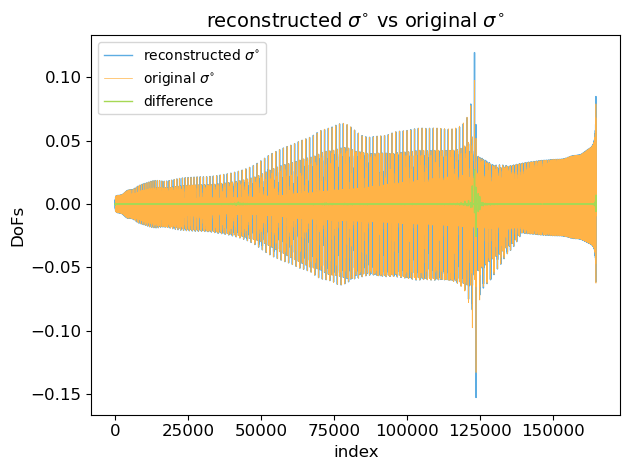

In [27]:
plt.plot(RT2_CG1_sigma_fc.x.array, label=r'reconstructed $\sigma^{\circ}$', color='#5DADE2', linewidth=1.0)  # warm blue
plt.plot(sigma_fc.x.array, label=r'original $\sigma^{\circ}$', color='#FFB347', linewidth=0.5)  # pastel orange
plt.plot(RT2_CG1_sigma_fc.x.array - sigma_fc.x.array, label='difference', color='#A6D854', linewidth=1.0)  # lime green

plt.xlabel('index', fontsize=12)
plt.ylabel('DoFs', fontsize=12)
plt.legend()
plt.title(r'reconstructed $\sigma^{\circ}$ vs original $\sigma^{\circ}$', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(f'sample_{sample_index}_RT2_CG1_sigma_fc_vs_sigma_fc.png')
plt.show()

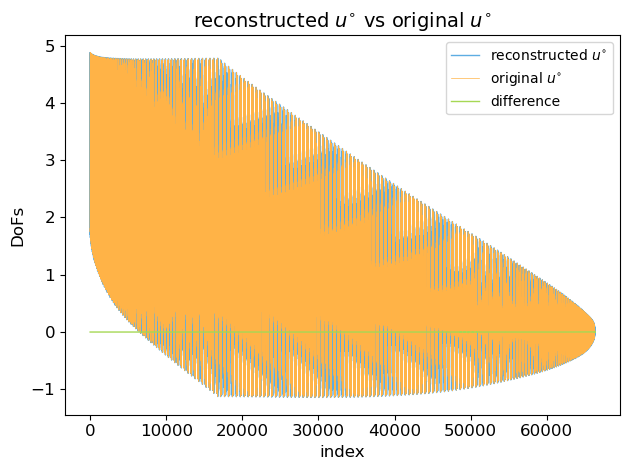

In [28]:
plt.plot(CG2_CG1_u_fc.x.array, label=r'reconstructed $u^{\circ}$', color='#5DADE2', linewidth=1.0)
plt.plot(u_fc.x.array, label=r'original $u^{\circ}$', color='#FFB347', linewidth=0.5)
plt.plot(CG2_CG1_u_fc.x.array - u_fc.x.array, label='difference', color='#A6D854', linewidth=1.0)
plt.xlabel('index', fontsize=12)
plt.ylabel('DoFs', fontsize=12)
plt.legend()
plt.title(r'reconstructed $u^{\circ}$ vs original $u^{\circ}$', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(f'sample_{sample_index}_CG2_CG1_u_fc_vs_u_fc.png')
plt.show()